In [79]:
from PIL import Image, ImageOps
from pillow_heif import register_heif_opener
import numpy as np
import sys 
import cv2
import matplotlib.pyplot as plt

In [80]:
register_heif_opener()
image = Image.open("Gold_Dots/NorahJones-ComeAwayWithMe.HEIC")  # Open the HEIC image file
image = ImageOps.exif_transpose(image)  # Correct orientation based on EXIF data
image = image.convert("RGB")  # Convert to RGB mode

rgb_array_original = np.array(image)  # Convert to NumPy array
bgr_array_original = rgb_array_original[..., ::-1]  # Convert RGB to BGR by reversing the last dimension

In [81]:
scale_factor = 1500 / max(bgr_array_original.shape[:2])  # scale so long edge = 1500px
small = cv2.resize(bgr_array_original, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_AREA)
rgb_array = np.array(small)[..., ::-1]  # Convert BGR back to RGB for displaying with matplotlib
bgr_array = np.array(small)  # Keep BGR for OpenCV processing

In [82]:
gray = cv2.cvtColor(bgr_array, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)
#Blurs the image to reduce noise and improve edge detection.
edges = cv2.Canny(blurred, 40, 120)



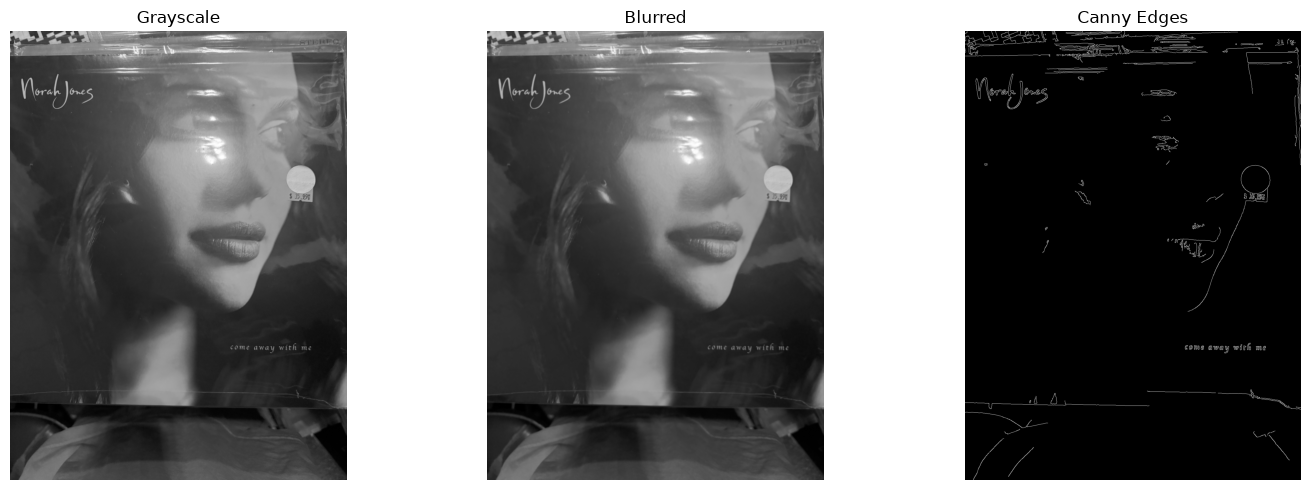

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale")
axes[0].axis("off")
 
axes[1].imshow(blurred, cmap="gray")
axes[1].set_title("Blurred")
axes[1].axis("off")
 
axes[2].imshow(edges, cmap="gray")
axes[2].set_title("Canny Edges")
axes[2].axis("off")
 
plt.tight_layout()
plt.show()

In [84]:
def line_score(line, width):
    x1, y1, x2, y2 = line
    length = np.hypot(x2 - x1, y2 - y1)
    width_span = abs(x2 - x1)  # horizontal reach, ignoring how much it's tilted
    return length * (width_span / width)  # penalize lines that don't span much of the frame

In [85]:
def merge_collinear_segments(segments, y_tolerance=20):
    """
    Group line segments that likely belong to the same physical edge (e.g.
    one edge broken into several pieces by glare) and merge each group into
    a single segment spanning its extreme left/right endpoints.

    Args:
        segments: list of (x1, y1, x2, y2) tuples, already filtered to be
                  roughly the same angle as each other
        y_tolerance: max difference in average y-position for two segments
                     to be considered part of the same edge

    Returns:
        list of merged (x1, y1, x2, y2) segments, one per cluster
    """
    if not segments:
        return []

    # sort by average y so segments belonging to the same edge end up adjacent
    segments = sorted(segments, key=lambda s: (s[1] + s[3]) / 2)

    clusters = []
    current_cluster = [segments[0]]
    current_y = (segments[0][1] + segments[0][3]) / 2

    for seg in segments[1:]:
        seg_y = (seg[1] + seg[3]) / 2
        if abs(seg_y - current_y) <= y_tolerance:
            current_cluster.append(seg)
        else:
            clusters.append(current_cluster)
            current_cluster = [seg]
        current_y = seg_y
    clusters.append(current_cluster)

    merged = []
    for cluster in clusters:
        # bridge glare-induced gaps by taking the overall leftmost and
        # rightmost endpoints across every fragment in the cluster
        all_points = [(s[0], s[1]) for s in cluster] + [(s[2], s[3]) for s in cluster]
        left_point = min(all_points, key=lambda p: p[0])
        right_point = max(all_points, key=lambda p: p[0])
        merged.append((left_point[0], left_point[1], right_point[0], right_point[1]))

    return merged


def find_matching_bottom_line(bottom_candidates, top_line, image_height, angle_tolerance=5, min_separation_frac=0.3):
    """
    Pick (or reconstruct) the bottom edge using the already-detected top edge
    as a prior: an album cover is roughly rectangular, so its bottom edge
    should have close to the same angle -- and, after merging any
    glare-fragmented pieces, close to the same length -- as the top edge.
    This is more robust than just grabbing the single longest bottom-half
    line, since the bottom edge is often the one broken up by glare and a
    stray line (hand, shadow, reflection) can otherwise get picked instead.

    Args:
        bottom_candidates: list of (x1, y1, x2, y2) roughly-horizontal lines
                            detected in the bottom half of the frame
        top_line: the already-resolved (x1, y1, x2, y2) top edge
        image_height: height of the image the lines were detected on --
                      used to enforce the minimum top/bottom separation
        angle_tolerance: degrees of allowed deviation from the top edge's angle
        min_separation_frac: minimum vertical separation required between a
                              candidate and the top edge, as a fraction of
                              image height. Enforced per (top_line, candidate)
                              pair rather than as an upfront filter on
                              bottom_candidates, since "far enough" depends on
                              where the top edge actually landed, not on a
                              fixed position in the frame

    Returns:
        best-matching (possibly merged) bottom line, or None if nothing in
        bottom_candidates has both a close enough angle to the top edge and
        sufficient separation from it
    """
    if not bottom_candidates or top_line is None:
        return None

    tx1, ty1, tx2, ty2 = top_line
    top_angle = np.degrees(np.arctan2(ty2 - ty1, tx2 - tx1))
    top_length = np.hypot(tx2 - tx1, ty2 - ty1)
    top_avg_y = (ty1 + ty2) / 2
    min_separation = min_separation_frac * image_height

    # keep only candidates whose angle roughly matches the top edge AND
    # whose separation from the top edge clears the minimum -- both are
    # properties of the (top_line, candidate) pairing, not of the candidate
    # considered on its own
    matching = []
    for seg in bottom_candidates:
        x1, y1, x2, y2 = seg
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        # normalize the angle difference (handles e.g. -179 vs 179 wraparound)
        angle_diff = abs((angle - top_angle + 180) % 360 - 180)
        seg_avg_y = (y1 + y2) / 2
        separation = abs(seg_avg_y - top_avg_y)
        if angle_diff <= angle_tolerance and separation >= min_separation:
            matching.append(seg)

    if not matching:
        return None

    # bridge glare-fragmented pieces of what may be the same physical edge
    merged_candidates = merge_collinear_segments(matching)

    # prefer whichever merged candidate has length closest to the top edge's
    best = min(
        merged_candidates,
        key=lambda seg: abs(np.hypot(seg[2] - seg[0], seg[3] - seg[1]) - top_length)
    )
    return best

In [86]:
def detect_top_bottom_lines(edges: np.ndarray, image_shape: tuple):
    """
    Run Hough line detection on a Canny edge map and isolate the best
    candidate lines for the album cover's top and bottom edges.
 
    Args:
        edges: binary edge map from cv2.Canny
        image_shape: (height, width) of the original image, used to split
                     candidate lines into "top half" vs "bottom half" and
                     to filter by minimum line length
 
    Returns:
        top_line, bottom_line -- each a tuple (x1, y1, x2, y2), or None if
        no suitable candidate was found for that edge
    """
    height, width = image_shape[:2]
 
    # HoughLinesP returns line segments directly (as opposed to HoughLines,
    # which returns infinite lines in polar form) -- segments are easier to
    # reason about here since we care about actual endpoints for corners.
    #
    # Tunable params:
    #   threshold        -- min votes for a line to be returned
    #   minLineLength    -- discard segments shorter than this (filters noise)
    #   maxLineGap       -- max gap allowed to still treat two segments as one line
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=150,
        minLineLength=width * 0.3,   # require lines to span a meaningful chunk of the frame
        maxLineGap=150
    )

    if lines is None:
        return None, None
 
    horizontal_lines = []
    for line in lines:
        x1, y1, x2, y2 = line
        
        # Angle relative to horizontal -- near 0 or near 180 degrees means "roughly horizontal"
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        if abs(angle) < 10 or abs(angle) > 170:  # tolerance for slight tilt
            horizontal_lines.append((x1, y1, x2, y2))
 
    if not horizontal_lines:
        return None, None
 
    # Top candidates are restricted to the top 20% of the frame -- the album
    # cover's top edge should start close to the top of the photo, and this
    # keeps interior horizontal lines (text, artwork detail) from being
    # mistaken for the top edge. Bottom candidates keep the looser "bottom
    # half of the frame" rule.
    top_candidates = [l for l in horizontal_lines if ((l[1] + l[3]) / 2) < height * 0.2]
    bottom_candidates = [l for l in horizontal_lines if ((l[1] + l[3]) / 2) >= height / 2]
 
    def longest(lines_list):
        if not lines_list:
            return None
        return max(lines_list, key=lambda l: np.hypot(l[2] - l[0], l[3] - l[1]))
 
    top_line = longest(top_candidates)

    if  np.hypot(top_line[2] - top_line[0], top_line[3] - top_line[1]) < width * 0.7:
        # if the top line is too short, increase length to edges of frame at the same y
        y_avg = (top_line[1] + top_line[3]) / 2
        top_line = (0, int(y_avg), width - 1, int(y_avg))

    # Top edge tends to be detected reliably; use it as a prior for the
    # bottom edge, which is more often broken up by glare. This filters out
    # candidates (e.g. a hand, a shadow) whose angle doesn't match the top
    # edge or that aren't far enough from it, and bridges any
    # glare-fragmented pieces of the real bottom edge into one segment
    # before picking the best length match.
    bottom_line = find_matching_bottom_line(bottom_candidates, top_line, height)
    if bottom_line is None:
        # fall back to the simple "longest candidate" approach if nothing
        # matched the top edge's angle/separation closely enough
        bottom_line = longest(bottom_candidates)
 
    return top_line, bottom_line

In [87]:
def build_bottom_roi_mask(top_line, image_shape, band_start_frac=0.7, band_end_frac=0.98):
    """
    Build a mask isolating the region where the bottom edge is expected to be,
    tilted to roughly follow the top edge's slope.
 
    Args:
        top_line: (x1, y1, x2, y2) of the detected top edge
        image_shape: (height, width) of the image
        band_start_frac: top of the search band, as a fraction of image height
                          below the top edge's average y (e.g. 0.7 = start
                          searching 70% of the way down the image)
        band_end_frac: bottom of the search band, as a fraction of image height
                        (e.g. 0.98 = search almost all the way to the bottom border)
 
    Returns:
        binary mask (same shape as image, single channel), 255 inside the band
    """
    height, width = image_shape[:2]
    x1, y1, x2, y2 = top_line
 
    # Top edge's slope -- used to tilt the band so it tracks the same tilt
    # as the top edge, on the assumption the bottom edge is roughly parallel
    slope = (y2 - y1) / (x2 - x1) if (x2 - x1) != 0 else 0
    top_avg_y = (y1 + y2) / 2
 
    band_top_y = top_avg_y + band_start_frac * height
    # band_bottom_y = band_start_frac * 0  # placeholder, computed per-column below
 
    mask = np.zeros((height, width), dtype=np.uint8)
 
    for x in range(width):
        # Project the band boundaries at this column, following the top edge's slope
        offset = slope * (x - (x1 + x2) / 2)
        col_band_top = int(np.clip(band_top_y + offset, 0, height - 1))
        col_band_bottom = int(np.clip(top_avg_y + band_end_frac * height + offset, 0, height - 1))
 
        if col_band_top < col_band_bottom:
            mask[col_band_top:col_band_bottom, x] = 255
 
    return mask

In [88]:
def extract_edge_points(edges: np.ndarray, roi_mask: np.ndarray) -> np.ndarray:
    """
    Get all edge pixel coordinates that fall within the ROI mask.
 
    Args:
        edges: binary Canny edge map
        roi_mask: binary mask from build_bottom_roi_mask
 
    Returns:
        Nx2 array of (x, y) points, or empty array if none found
    """
    masked_edges = cv2.bitwise_and(edges, roi_mask)
    ys, xs = np.where(masked_edges == 255)
    points = np.column_stack((xs, ys))
    return points

In [89]:
def _line_through_two_points(p1: np.ndarray, p2: np.ndarray):
    """Slope/intercept for the line through two (x, y) points. None if vertical."""
    x1, y1 = p1
    x2, y2 = p2
    if x2 - x1 == 0:
        return None
    slope = (y2 - y1) / (x2 - x1)
    intercept = y1 - slope * x1
    return slope, intercept

def _point_line_distance(points: np.ndarray, slope: float, intercept: float) -> np.ndarray:
    """
    Perpendicular distance from each point to the line y = slope*x + intercept,
    vectorized across all points at once.
    """
    # Line in standard form: slope*x - y + intercept = 0
    a, b, c = slope, -1.0, intercept
    denom = np.sqrt(a ** 2 + b ** 2)
    return np.abs(a * points[:, 0] + b * points[:, 1] + c) / denom

In [90]:
def fit_bottom_line_ransac(points: np.ndarray, n_iterations=300, inlier_threshold=3.0, min_inliers=10, random_seed=None):
    """
    Fit a line through the dominant consistent cluster of points, ignoring
    unrelated clusters (e.g. a seam) using RANSAC.
 
    Rather than fitting to the whole point cloud at once -- which blends
    together any distinct clusters present (real edge vs. seam) -- this
    repeatedly samples 2 random points, checks how many other points agree
    with the resulting line within `inlier_threshold` pixels, and keeps
    whichever random line had the most support. The final line is then
    refit using only that winning inlier set.
 
    Args:
        points: Nx2 array of (x, y) edge pixel coordinates
        n_iterations: number of random 2-point samples to try
        inlier_threshold: max perpendicular distance (pixels) for a point to
                           count as supporting a candidate line
        min_inliers: minimum inlier count required to accept a fit at all
        random_seed: optional, for reproducible results while testing
 
    Returns:
        (slope, intercept, inlier_points) or None if no good line was found
    """
    if points.shape[0] < min_inliers:
        return None
 
    points_float = points.astype(np.float64)
    rng = np.random.default_rng(random_seed)
 
    best_inlier_count = 0
    best_inlier_mask = None
 
    for _ in range(n_iterations):
        idx = rng.choice(points_float.shape[0], size=2, replace=False)
        p1, p2 = points_float[idx[0]], points_float[idx[1]]
 
        line = _line_through_two_points(p1, p2)
        if line is None:
            continue
        slope, intercept = line
 
        distances = _point_line_distance(points_float, slope, intercept)
        inlier_mask = distances <= inlier_threshold
        inlier_count = np.count_nonzero(inlier_mask)
 
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inlier_mask = inlier_mask
 
    if best_inlier_mask is None or best_inlier_count < min_inliers:
        return None
 
    # Refit using only the winning inlier set, via cv2.fitLine for a clean
    # final result (no outliers left to worry about at this point)
    inlier_points = points_float[best_inlier_mask].astype(np.float32)
    vx, vy, x0, y0 = cv2.fitLine(inlier_points, distType=cv2.DIST_L2, param=0, reps=0.01, aeps=0.01).flatten()
 
    if vx == 0:  # vertical line, degenerate case for slope-intercept form
        return None
 
    slope = vy / vx
    intercept = y0 - slope * x0
 
    return slope, intercept, inlier_points

In [91]:
def bottom_corners_from_fit(slope: float, intercept: float, width: int):
    """
    Extrapolate the fitted line to the image's left/right boundaries to get
    the bottom-left and bottom-right corner points.
 
    Args:
        slope, intercept: from fit_bottom_line
        width: image width
 
    Returns:
        (bottom_left, bottom_right) as (x, y) tuples
    """
    y_at_left = intercept  # x = 0
    y_at_right = slope * width + intercept  # x = width
 
    bottom_left = (0, y_at_left)
    bottom_right = (width, y_at_right)
 
    return bottom_left, bottom_right

In [92]:
def slopes_agree(top_line, fitted_slope, max_angle_diff_degrees=10):
    x1, y1, x2, y2 = top_line
    top_slope = (y2 - y1) / (x2 - x1) if (x2 - x1) != 0 else 0

    top_angle = np.degrees(np.arctan(top_slope))
    bottom_angle = np.degrees(np.arctan(fitted_slope))

    return abs(top_angle - bottom_angle) <= max_angle_diff_degrees

In [93]:
def resolve_bottom_edge(top_line, edges: np.ndarray, image_shape, max_angle_diff_degrees=15.0, verbose=False):
    """
    Full pipeline: ROI mask -> point extraction -> RANSAC fit -> slope check
    -> extrapolated corners.
 
    Args:
        top_line: (x1, y1, x2, y2) from existing Hough-based top edge detection
        edges: binary Canny edge map
        image_shape: (height, width) of the image
        max_angle_diff_degrees: tolerance for the fitted bottom line's slope
                                 vs. the top edge's slope; fits outside this
                                 tolerance are rejected rather than trusted
        verbose: if True, prints why a None was returned (useful while tuning)
 
    Returns:
        (bottom_left, bottom_right) corner points, or None if no confident
        fit could be resolved (too few points, RANSAC found no good line, or
        the best line found doesn't agree with the top edge's slope)
    """
    roi_mask = build_bottom_roi_mask(top_line, image_shape)
    points = extract_edge_points(edges, roi_mask)
    fit_result = fit_bottom_line_ransac(points)
 
    if fit_result is None:
        if verbose:
            print("RANSAC found no line with sufficient inlier support")
        return None
 
    slope, intercept, inlier_points = fit_result
 
    if not slopes_agree(top_line, slope, max_angle_diff_degrees):
        if verbose:
            print(f"Best RANSAC line's slope disagrees with top edge beyond "
                  f"{max_angle_diff_degrees} degrees -- rejecting fit")
        return None
 
    width = image_shape[1]
    return bottom_corners_from_fit(slope, intercept, width)

In [94]:
def visualize_fit(image_bgr: np.ndarray, roi_mask: np.ndarray, points: np.ndarray, bottom_left, bottom_right):
    """Sanity-check plot: ROI band, raw candidate points, and the final fitted line."""
    vis = image_bgr.copy()
 
    # Tint the ROI band so you can see what region was searched
    overlay = vis.copy()
    overlay[roi_mask == 255] = (0, 100, 0)
    vis = cv2.addWeighted(overlay, 0.3, vis, 0.7, 0)
 
    # Draw the candidate edge points that went into the fit
    for x, y in points:
        cv2.circle(vis, (int(x), int(y)), 2, (0, 255, 255), -1)
 
    # Draw the final fitted/extrapolated line
    if bottom_left is not None and bottom_right is not None:
        cv2.line(vis, (int(bottom_left[0]), int(bottom_left[1])),
                  (int(bottom_right[0]), int(bottom_right[1])), (0, 0, 255), 3)
 
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("ROI (green tint) / candidate points (yellow) / fitted line (red)")
    plt.axis("off")
    plt.show()

In [95]:
def visualize_lines(image_bgr: np.ndarray, top_line, bottom_line):
    """Draw the detected top/bottom lines on a copy of the image for a sanity check."""
    vis = image_bgr.copy()
    if top_line is not None:
        x1, y1, x2, y2 = top_line
        cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 3)  # green
    if bottom_line is not None:
        x1, y1, x2, y2 = bottom_line
        cv2.line(vis, (x1, y1), (x2, y2), (0, 0, 255), 3)  # red
 
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("Detected top (green) / bottom (red) lines")
    plt.axis("off")
    plt.show()
 

In [96]:
def resolve_corners(top_line, bottom_line, image_shape):
    """
    Given top and bottom edge line segments, resolve the 4 corner points of
    the album cover. Left/right endpoints of each line are used directly if
    they terminate within the frame; if a line's detected endpoint sits at
    (or very near) the image border, that's treated as evidence the true
    corner is off-frame, and the border coordinate is used as-is (since it's
    already the frame edge).
 
    Args:
        top_line: (x1, y1, x2, y2) or None
        bottom_line: (x1, y1, x2, y2) or None
        image_shape: (height, width) of the original image
 
    Returns:
        A 4x2 numpy array of corners in order:
        [top-left, top-right, bottom-right, bottom-left]
        or None if either line is missing (can't proceed without both anchors)
    """
    if top_line is None or bottom_line is None:
        return None
 
    height, width = image_shape[:2]
 
    def sorted_endpoints(line):
        x1, y1, x2, y2 = line
        # Return left point first, right point second, regardless of detection order
        if x1 <= x2:
            return (x1, y1), (x2, y2)
        else:
            return (x2, y2), (x1, y1)
 
    top_left, top_right = sorted_endpoints(top_line)
    bottom_left, bottom_right = sorted_endpoints(bottom_line)
 
    corners = np.array([top_left, top_right, bottom_right, bottom_left], dtype="float32")
    return corners

In [97]:
def warp_to_rectangle(image_bgr: np.ndarray, corners: np.ndarray, output_size=(600, 600)):
    """
    Apply a perspective transform to flatten the region defined by `corners`
    into a uniform rectangle.
 
    Args:
        image_bgr: source image
        corners: 4x2 array [top-left, top-right, bottom-right, bottom-left]
        output_size: (width, height) of the output rectangle
 
    Returns:
        warped image as a numpy array of shape (output_size[1], output_size[0], 3)
    """
    out_w, out_h = output_size
 
    destination = np.array([
        [0, 0],
        [out_w - 1, 0],
        [out_w - 1, out_h - 1],
        [0, out_h - 1]
    ], dtype="float32")
 
    transform_matrix = cv2.getPerspectiveTransform(corners, destination)
    warped = cv2.warpPerspective(image_bgr, transform_matrix, (out_w, out_h))
 
    return warped

In [98]:
def visualize_warp(warped_bgr: np.ndarray):
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2RGB))
    plt.title("Warped / perspective-corrected")
    plt.axis("off")
    plt.show()

In [99]:
def rescale_corners(corners: np.ndarray, scale_factor: float) -> np.ndarray:
    """
    Map corner coordinates found on a downscaled image back to their
    equivalent position on the original full-resolution image.

    Args:
        corners: 4x2 array of corner points, in the downscaled image's coordinate space
        scale_factor: the factor originally used to shrink the image
                      (e.g. 0.3 if you scaled to 30% of original size)

    Returns:
        4x2 array of corners in the original full-resolution image's coordinate space
    """
    return corners / scale_factor

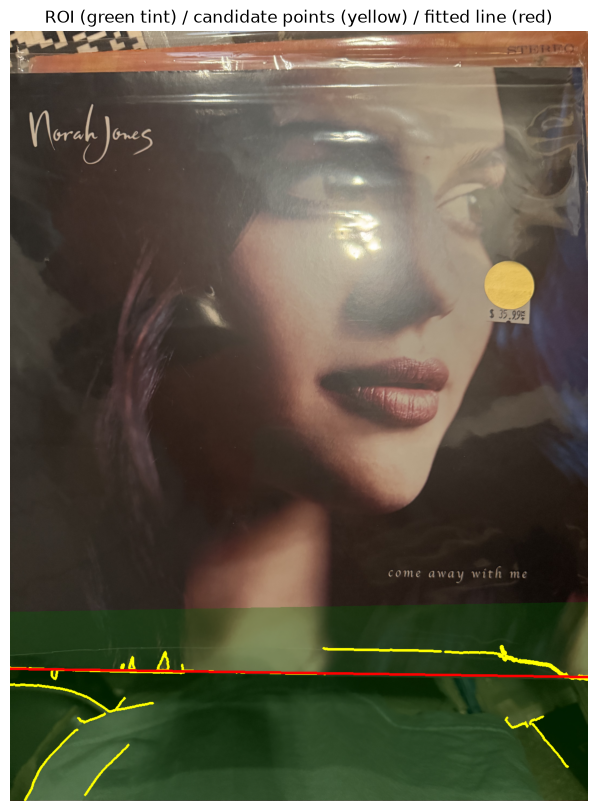

In [100]:
top_line, bottom_line = detect_top_bottom_lines(edges, bgr_array.shape)
bottom_corners = resolve_bottom_edge(top_line, edges, bgr_array.shape, verbose=True)

if bottom_corners is not None:
    bottom_left, bottom_right = bottom_corners

    # for visualization -- rerun the intermediate steps to get the points to plot
    roi_mask = build_bottom_roi_mask(top_line, bgr_array.shape)
    points = extract_edge_points(edges, roi_mask)
    visualize_fit(bgr_array, roi_mask, points, bottom_left, bottom_right)
else:
    print("Could not confidently resolve the bottom edge -- see verbose output above")

# --- to get all 4 corners for resolve_corners / warp_to_rectangle ---
# top_left, top_right = sorted endpoints of top_line (same logic as before)
# corners = np.array([top_left, top_right, bottom_right, bottom_left], dtype="float32")
 

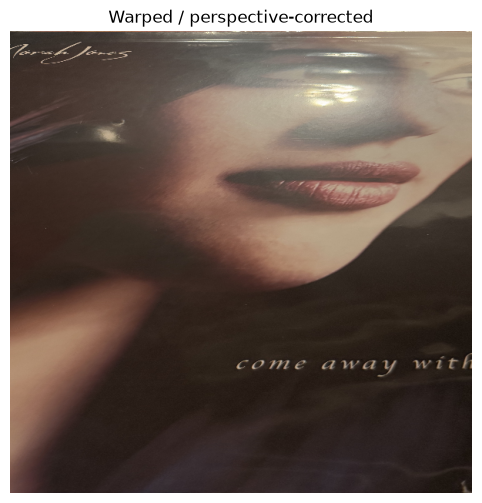

In [101]:
# on the downscaled image
top_line, bottom_line = detect_top_bottom_lines(edges, small.shape)
corners_small = resolve_corners(top_line, bottom_line, small.shape)

# map back up to full resolution
corners_full = rescale_corners(corners_small, scale_factor)

# warp against the ORIGINAL full-res image, using full-res corners
warped = warp_to_rectangle(bgr_array_original, corners_full)
visualize_warp(warped)

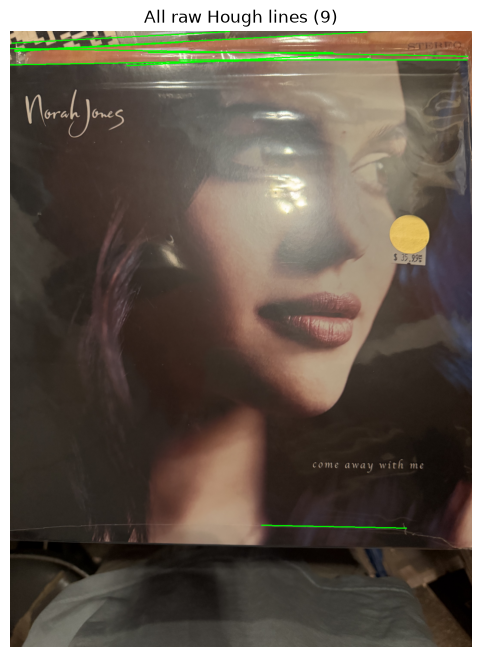

In [102]:
# Display every raw Hough line on the photo without changing the existing pipeline.
raw_lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=150,
    minLineLength=bgr_array.shape[1] * 0.3,
    maxLineGap=200,
)

raw_lines_overlay = bgr_array.copy()
raw_line_count = 0 if raw_lines is None else len(raw_lines)

if raw_lines is not None:
    for raw_line in raw_lines:
        x1, y1, x2, y2 = raw_line
        cv2.line(raw_lines_overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)
        raw_line_count += 0

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(raw_lines_overlay, cv2.COLOR_BGR2RGB))
plt.title(f"All raw Hough lines ({raw_line_count})")
plt.axis("off")
plt.show()

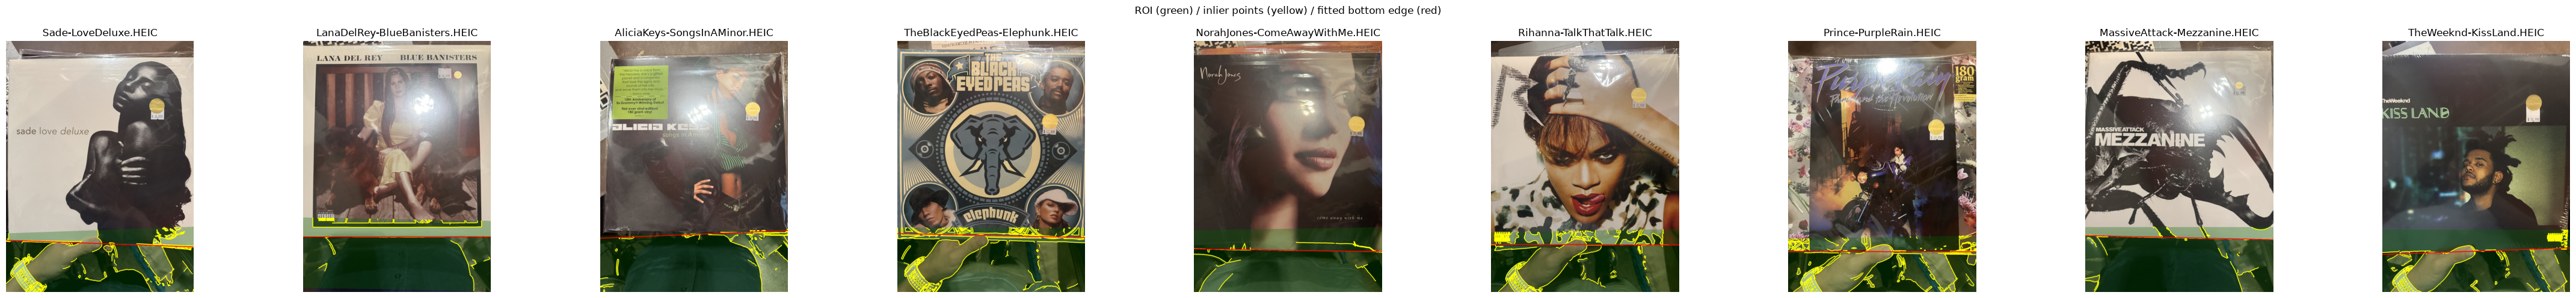

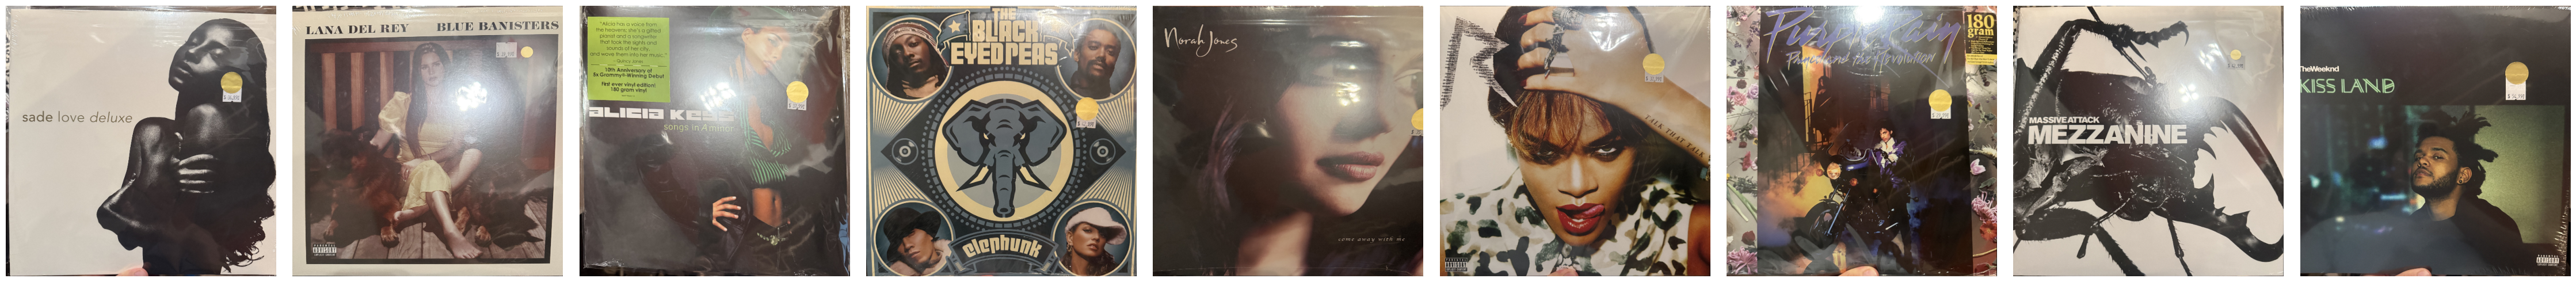

In [103]:
sample_files = [
    "Gold_Dots/Sade-LoveDeluxe.HEIC",
    "Gold_Dots/LanaDelRey-BlueBanisters.HEIC",
    "Gold_Dots/AliciaKeys-SongsInAMinor.HEIC",
    "Gold_Dots/TheBlackEyedPeas-Elephunk.HEIC",
    "Gold_Dots/NorahJones-ComeAwayWithMe.HEIC",
    "Gold_Dots/Rihanna-TalkThatTalk.HEIC",
    "Gold_Dots/Prince-PurpleRain.HEIC",
    "Gold_Dots/MassiveAttack-Mezzanine.HEIC",
    "Gold_Dots/TheWeeknd-KissLand.HEIC"
]
 
 
def sorted_endpoints(line):
    """Left point first, right point second, regardless of detection order."""
    x1, y1, x2, y2 = line
    if x1 <= x2:
        return (x1, y1), (x2, y2)
    else:
        return (x2, y2), (x1, y1)
 
 
results = []  # holds per-image data needed for both plots
 
for file in sample_files:
    image = Image.open(file)
    image = ImageOps.exif_transpose(image)
    image = image.convert("RGB")
 
    rgb_array_full = np.array(image)
    bgr_array_full = rgb_array_full[..., ::-1]  # full-resolution, BGR
 
    # downscale before edge/line detection -- full-res glare gaps blow past
    # maxLineGap and break Hough otherwise
    file_scale_factor = 1500 / max(bgr_array_full.shape[:2])
    small = cv2.resize(bgr_array_full, None, fx=file_scale_factor, fy=file_scale_factor,
                        interpolation=cv2.INTER_AREA)
 
    gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 40, 120)
 
    top_line, _ = detect_top_bottom_lines(edges, small.shape)
 
    if top_line is None:
        print(f"Skipping {file}: couldn't detect top edge")
        results.append({"file": file, "warped": None, "roi_mask": None,
                         "points": None, "bottom_left": None, "bottom_right": None})
        continue
 
    bottom_corners = resolve_bottom_edge(top_line, edges, small.shape, verbose=True)
 
    if bottom_corners is None:
        print(f"Skipping {file}: couldn't confidently resolve bottom edge")
        results.append({"file": file, "warped": None, "roi_mask": None,
                         "points": None, "bottom_left": None, "bottom_right": None})
        continue
 
    bottom_left, bottom_right = bottom_corners
 
    # grab the ROI/points too, purely for the diagnostic visualization below
    roi_mask = build_bottom_roi_mask(top_line, small.shape)
    points = extract_edge_points(edges, roi_mask)
 
    top_left, top_right = sorted_endpoints(top_line)
    corners_small = np.array([top_left, top_right, bottom_right, bottom_left], dtype="float32")
 
    # map back up to full resolution, then warp against THIS file's full-res image
    corners_full = rescale_corners(corners_small, file_scale_factor)
    warped = warp_to_rectangle(bgr_array_full, corners_full)
 
    results.append({
        "file": file,
        "warped": warped,
        "small": small,
        "roi_mask": roi_mask,
        "points": points,
        "bottom_left": bottom_left,
        "bottom_right": bottom_right,
    })
 
 
# --- Plot 1: fit diagnostics (ROI band / inlier points / fitted line) per image ---
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5))
if len(results) == 1:
    axes = [axes]
 
for ax, r in zip(axes, results):
    if r["warped"] is None:
        ax.set_title(f"{r['file'].split('/')[-1]}\n(failed)")
        ax.axis("off")
        continue
 
    vis = r["small"].copy()
    overlay = vis.copy()
    overlay[r["roi_mask"] == 255] = (0, 100, 0)
    vis = cv2.addWeighted(overlay, 0.3, vis, 0.7, 0)
 
    for x, y in r["points"]:
        cv2.circle(vis, (int(x), int(y)), 2, (0, 255, 255), -1)
 
    bl, br = r["bottom_left"], r["bottom_right"]
    cv2.line(vis, (int(bl[0]), int(bl[1])), (int(br[0]), int(br[1])), (0, 0, 255), 3)
 
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(r["file"].split("/")[-1])
    ax.axis("off")
 
plt.suptitle("ROI (green) / inlier points (yellow) / fitted bottom edge (red)")
plt.tight_layout()
plt.show()
 
 
# --- Plot 2: final warped/cropped output per image ---
cropped_photos = [r["warped"] for r in results if r["warped"] is not None]
 
fig, axes = plt.subplots(1, len(cropped_photos), figsize=(5 * len(cropped_photos), 5))
if len(cropped_photos) == 1:
    axes = [axes]
 
for ax, cropped in zip(axes, cropped_photos):
    ax.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
    ax.axis("off")
 
plt.tight_layout()
plt.show()
 